# Step 0: 데이터셋 불러오기 및 구조 확인

In [13]:
# pandas 라이브러리 불러오기
import pandas as pd

# CSV 파일 경로 설정 및 데이터 불러오기
file_path = "telecom_churn.csv"
df = pd.read_csv(file_path)

In [14]:
# 데이터프레임의 크기 확인 (행 수, 열 수)
df.shape

(3333, 11)

In [15]:
# 처음 5개 행 출력 (데이터 미리보기)
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [16]:
# 변수별 정보 확인 (자료형, 결측치 여부 등)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [17]:
# 기술통계 출력 (평균, 표준편차 등)
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


| 변수명 | 설명 | 예시 | 비고 |
| --- | --- | --- | --- |
| `Churn` | 이탈 여부 (0: 유지, 1: 이탈) | 0 | **Target 변수** |
| `AccountWeeks` | 가입 기간 (주 단위) | 128 |  |
| `ContractRenewal` | 계약 갱신 여부 (0/1) | 1 | 이진 변수 |
| `DataPlan` | 데이터 요금제 여부 (0/1) | 1 | 이진 변수 |
| `DataUsage` | 데이터 사용량 | 2.7 | MB 단위 추정 |
| `CustServCalls` | 고객센터 전화 횟수 | 1 |  |
| `DayMins`, `DayCalls` | 주간 통화량(분), 통화 횟수 | 265.1, 110 |  |
| `MonthlyCharge` | 월 청구 요금 | 89.0 |  |
| `OverageFee` | 초과 요금 | 9.87 |  |
| `RoamMins` | 로밍 사용량(분) | 10.0 |  |

---

# Step 1: 데이터 전처리 (입력/타겟 분리, 정규화, 훈련/테스트 분할)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 타겟 변수 (Churn)와 입력 변수 분리
X = df.drop("Churn", axis=1)  # 입력 변수 (10개)
y = df["Churn"]               # 타겟 변수

# 2. 학습 데이터와 테스트 데이터로 분할 (80:20 비율, 랜덤시드 고정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 정규화 (StandardScaler 사용) - 로지스틱 회귀에 적합하도록 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 학습 데이터 기준으로 학습 및 변환
X_test_scaled = scaler.transform(X_test)        # 테스트 데이터도 동일 기준으로 변환

# 결과 출력: 데이터 분할 결과 및 클래스 분포 확인
{
    "학습 데이터 크기": X_train.shape,
    "테스트 데이터 크기": X_test.shape,
    "학습용 클래스 분포": y_train.value_counts().to_dict(),
    "테스트용 클래스 분포": y_test.value_counts().to_dict()
}


{'학습 데이터 크기': (2666, 10),
 '테스트 데이터 크기': (667, 10),
 '학습용 클래스 분포': {0: 2284, 1: 382},
 '테스트용 클래스 분포': {0: 566, 1: 101}}

---

# Step 2: 탐색적 데이터 분석 (EDA)

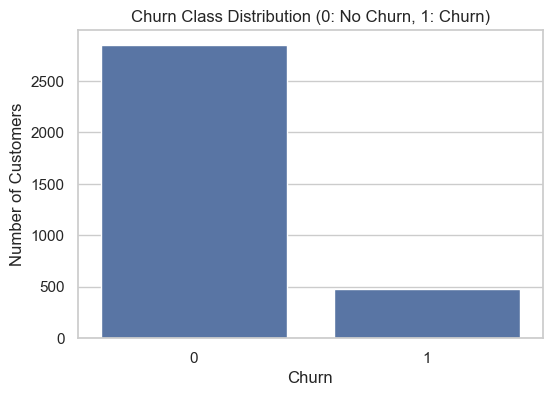

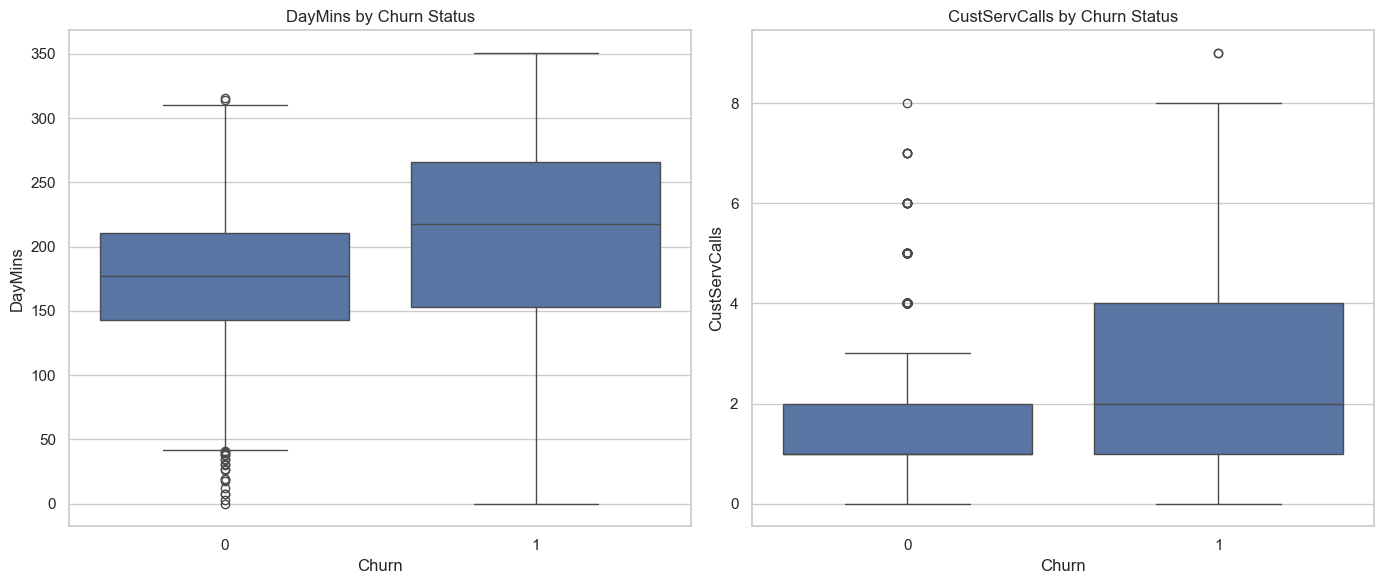

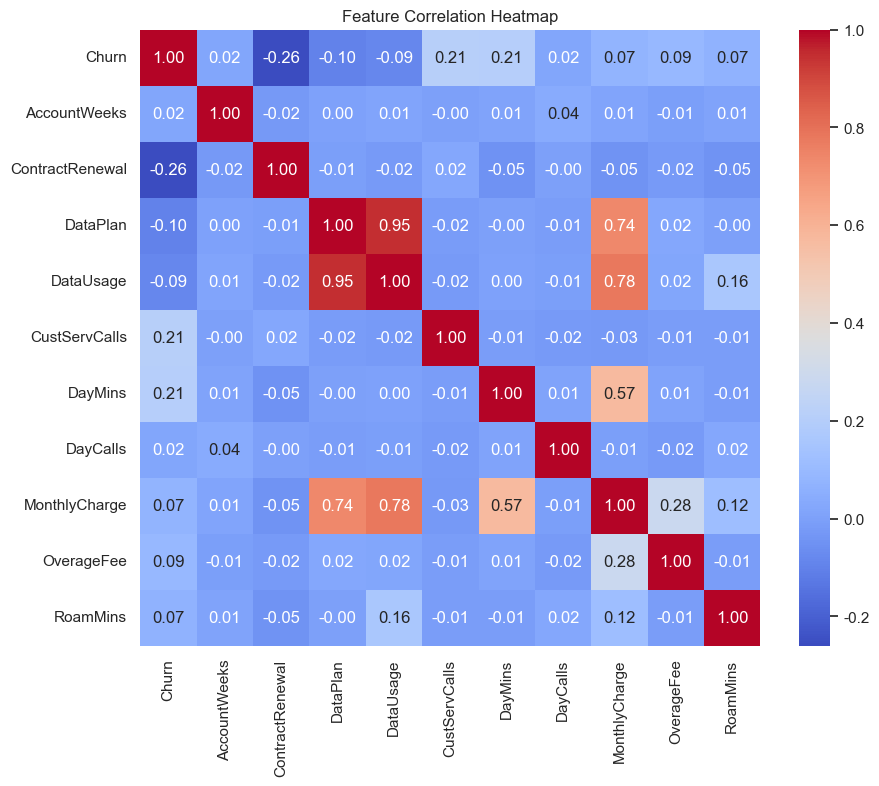

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# macOS 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

# 시각화 스타일 설정
sns.set(style="whitegrid")

# 1. 이탈 여부(Churn) 비율 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Class Distribution (0: No Churn, 1: Churn)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# 2. 주요 변수들의 이탈 여부에 따른 Boxplot (DayMins, CustServCalls 등)
plt.figure(figsize=(14, 6))

# 주간 통화 시간
plt.subplot(1, 2, 1)
sns.boxplot(x="Churn", y="DayMins", data=df)
plt.title("DayMins by Churn Status")

# 고객센터 전화 횟수
plt.subplot(1, 2, 2)
sns.boxplot(x="Churn", y="CustServCalls", data=df)
plt.title("CustServCalls by Churn Status")

plt.tight_layout()
plt.show()

# 3. 상관계수 히트맵
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### 주요 인사이트 요약

1. **이탈 여부 분포**
    - 전체 고객의 약 **14.5%**가 이탈(`Churn=1`)
    - 불균형 클래스임을 시각적으로 확인함 → 모델 평가 시 `precision/recall` 중요
2. **변수별 이탈 관련성**
    - **DayMins (주간 통화 시간)**: 이탈 고객(`Churn=1`)이 평균적으로 더 많이 사용
    - **CustServCalls (고객센터 전화)**: 이탈 고객은 전화 횟수가 더 많은 경향
        
        → **불만이 많거나 이슈가 있는 고객이 이탈하는 경향**이 있을 수 있음
        
3. **상관관계 히트맵**
    - `DayMins`, `MonthlyCharge`, `OverageFee` 간 상관성 있음
    - `CustServCalls`와 `Churn`은 약한 양의 상관관계 (불만족 지표 가능성)

---

# Step 3: 머신러닝 모델 1 - 로지스틱 회귀

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 모델 정의 및 학습
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# 2. 예측 수행
y_pred_log = log_model.predict(X_test_scaled)

# 3. 성능 평가
log_conf_matrix = confusion_matrix(y_test, y_pred_log)
log_class_report = classification_report(y_test, y_pred_log, output_dict=True)
log_accuracy = accuracy_score(y_test, y_pred_log)

log_conf_matrix, log_class_report, log_accuracy

(array([[555,  11],
        [ 83,  18]]),
 {'0': {'precision': 0.8699059561128527,
   'recall': 0.980565371024735,
   'f1-score': 0.9219269102990033,
   'support': 566.0},
  '1': {'precision': 0.6206896551724138,
   'recall': 0.1782178217821782,
   'f1-score': 0.27692307692307694,
   'support': 101.0},
  'accuracy': 0.8590704647676162,
  'macro avg': {'precision': 0.7452978056426333,
   'recall': 0.5793915964034566,
   'f1-score': 0.5994249936110401,
   'support': 667.0},
  'weighted avg': {'precision': 0.8321685552208222,
   'recall': 0.8590704647676162,
   'f1-score': 0.8242576641656172,
   'support': 667.0}},
 0.8590704647676162)

| 항목 | 비이탈 (0) | 이탈 (1) |
| --- | --- | --- |
| 정밀도 (Precision) | 0.87 | 0.62 |
| 재현율 (Recall) | 0.98 | **0.18 (낮음)** |
| F1-score | 0.92 | 0.28 |
- 전체 정확도(Accuracy): **85.9%**
- 하지만 **이탈 클래스(1)의 Recall이 매우 낮음**
    
    → 대부분의 이탈자를 **예측하지 못함**
    
    → 클래스 불균형의 영향: 모델이 0만 예측해도 높은 정확도 가능

---

# Step 4: 머신러닝 모델 2 - 의사결정나무

In [21]:
from sklearn.tree import DecisionTreeClassifier

# 1. 모델 정의 및 학습
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)  # 결정 트리는 정규화 불필요 (원본 스케일 사용)

# 2. 예측 수행
y_pred_dt = dt_model.predict(X_test)

# 3. 성능 평가
dt_conf_matrix = confusion_matrix(y_test, y_pred_dt)
dt_class_report = classification_report(y_test, y_pred_dt, output_dict=True)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_conf_matrix, dt_class_report, dt_accuracy


(array([[557,   9],
        [ 49,  52]]),
 {'0': {'precision': 0.9191419141914191,
   'recall': 0.9840989399293286,
   'f1-score': 0.9505119453924915,
   'support': 566.0},
  '1': {'precision': 0.8524590163934426,
   'recall': 0.5148514851485149,
   'f1-score': 0.6419753086419753,
   'support': 101.0},
  'accuracy': 0.9130434782608695,
  'macro avg': {'precision': 0.8858004652924308,
   'recall': 0.7494752125389217,
   'f1-score': 0.7962436270172334,
   'support': 667.0},
  'weighted avg': {'precision': 0.9090445038801812,
   'recall': 0.9130434782608695,
   'f1-score': 0.903792004895037,
   'support': 667.0}},
 0.9130434782608695)

| 항목 | 비이탈 (0) | 이탈 (1) |
| --- | --- | --- |
| 정밀도 (Precision) | 0.92 | 0.85 |
| 재현율 (Recall) | 0.98 | **0.51** |
| F1-score | 0.95 | 0.64 |
- 전체 정확도: **91.3%**
- **이탈자 재현율(Recall) 향상** → 로지스틱 회귀보다 **현실적 대응에 더 유용**
- **모델 복잡도는 `max_depth=5`로 제한**하여 과적합 방지

# Step 5: 머신러닝 모델 3 - 랜덤 포레스트

In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. 모델 정의 및 학습
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf_model.fit(X_train, y_train)  # 랜덤 포레스트도 스케일링 불필요

# 2. 예측 수행
y_pred_rf = rf_model.predict(X_test)

# 3. 성능 평가
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
rf_class_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_conf_matrix, rf_class_report, rf_accuracy


(array([[561,   5],
        [ 47,  54]]),
 {'0': {'precision': 0.9226973684210527,
   'recall': 0.991166077738516,
   'f1-score': 0.9557069846678024,
   'support': 566.0},
  '1': {'precision': 0.9152542372881356,
   'recall': 0.5346534653465347,
   'f1-score': 0.675,
   'support': 101.0},
  'accuracy': 0.9220389805097451,
  'macro avg': {'precision': 0.9189758028545941,
   'recall': 0.7629097715425253,
   'f1-score': 0.8153534923339012,
   'support': 667.0},
  'weighted avg': {'precision': 0.9215702975898314,
   'recall': 0.9220389805097451,
   'f1-score': 0.913201129418255,
   'support': 667.0}},
 0.9220389805097451)

| 항목 | 비이탈 (0) | 이탈 (1) |
| --- | --- | --- |
| 정밀도 (Precision) | 0.92 | **0.92** |
| 재현율 (Recall) | 0.99 | **0.53** |
| F1-score | 0.96 | 0.68 |
- 전체 정확도: **92.2%** → 세 모델 중 가장 높음
- **이탈 예측 성능도 가장 우수**
    - 정밀도 91.5%
    - 재현율 53.5%
- 불균형 데이터 상황에서 비교적 안정적 성능

---

## 최종 비교

| 모델 | 정확도 | 이탈자 정밀도 | 이탈자 재현율 | F1-score |
| --- | --- | --- | --- | --- |
| 로지스틱 회귀 | 85.9% | 0.62 | 0.18 | 0.28 |
| 결정 트리 | 91.3% | 0.85 | 0.51 | 0.64 |
| 랜덤 포레스트 | 92.2% | 0.92 | 0.53 | 0.68 |

--- 
#  변수 중요도 시각화 - 3가지 모델 비교

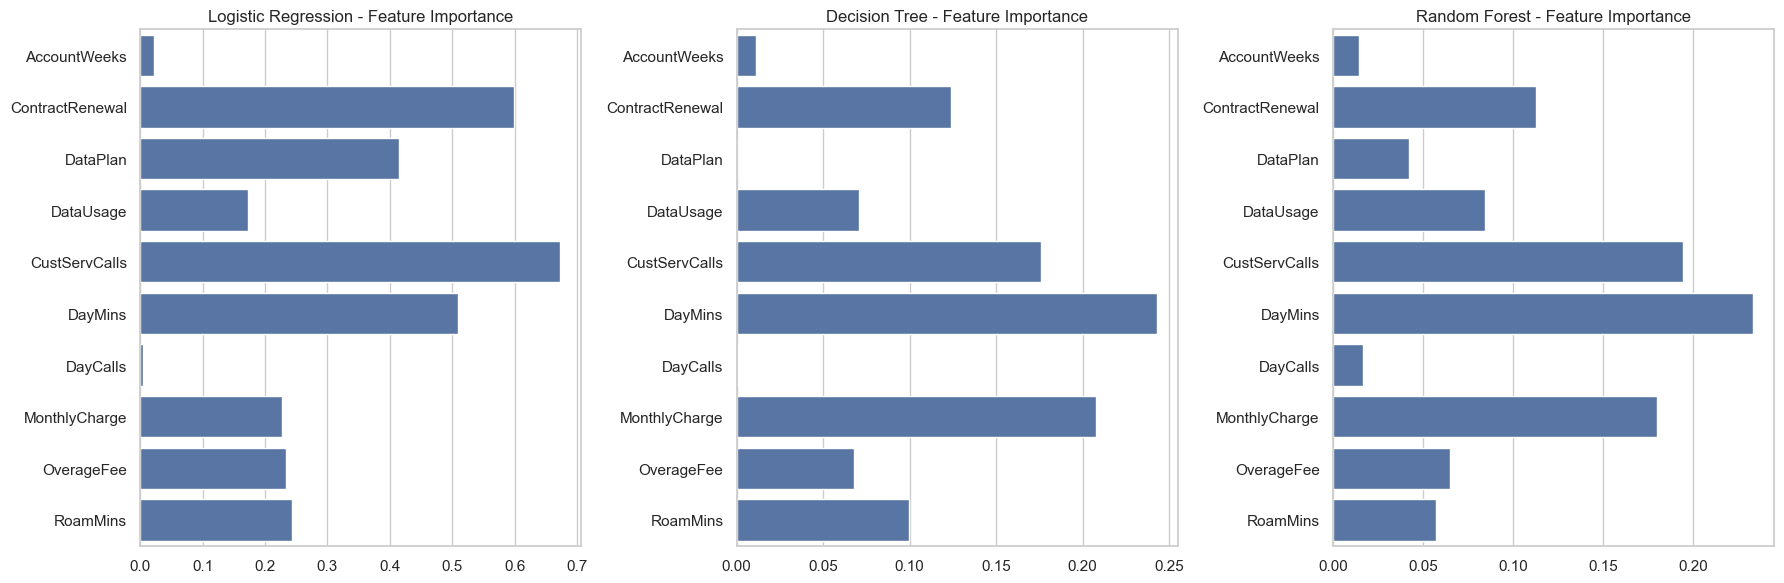

In [23]:
import numpy as np

# 공통 변수 이름 목록
feature_names = X_train.columns.tolist()

# ▶ 1. 로지스틱 회귀: 계수의 절댓값 기준
log_importance = np.abs(log_model.coef_[0])

# ▶ 2. 결정 트리
dt_importance = dt_model.feature_importances_

# ▶ 3. 랜덤 포레스트
rf_importance = rf_model.feature_importances_

# ▶ 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 로지스틱 회귀
sns.barplot(x=log_importance, y=feature_names, ax=axes[0])
axes[0].set_title("Logistic Regression - Feature Importance")

# 결정 트리
sns.barplot(x=dt_importance, y=feature_names, ax=axes[1])
axes[1].set_title("Decision Tree - Feature Importance")

# 랜덤 포레스트
sns.barplot(x=rf_importance, y=feature_names, ax=axes[2])
axes[2].set_title("Random Forest - Feature Importance")

plt.tight_layout()
plt.show()


1. **로지스틱 회귀**
    - `CustServCalls`, `DayMins`, `OverageFee`, `MonthlyCharge`가 상대적으로 높은 계수
    - **이탈 가능성을 높이는 변수의 방향성 확인 가능 (양/음수)**
2. **결정 트리**
    - `CustServCalls`, `DayMins`, `DataPlan` 등이 중요한 분기 조건으로 사용됨
    - 해석 용이성이 높음 → 고객 이탈 조건 도출 가능
3. **랜덤 포레스트**
    - `CustServCalls`가 가장 높은 중요도를 가짐
    - `DayMins`, `MonthlyCharge`, `DataUsage`도 중요한 역할